# Decision-Theoretic Inference & Risk Communication

## Introduction

This closing lesson of Section 24 ties together every uncertainty-quantification technique from the section — Bayesian NNs, VI, VAEs, diffusion, calibration, MC Dropout, ensembles, BO, and ArviZ diagnostics — into the one question that actually matters in production: **given a well-calibrated posterior, what action should you take?** This is statistical decision theory: converting a distribution over outcomes into a decision, and communicating that decision's risk to stakeholders who don't read posterior plots.

## Theory

### The decision-theoretic framework

A decision problem has: a set of possible actions $\mathcal{A}$, a set of states of the world $\Theta$ (unknown, described by the posterior $p(\theta|\mathcal{D})$), and a **loss function** $L(a, \theta)$ quantifying the cost of taking action $a$ when the true state is $\theta$. The **Bayes-optimal action** minimizes posterior expected loss:

$$
a^* = \arg\min_{a \in \mathcal{A}} \mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}\left[L(a, \theta)\right] = \arg\min_a \int L(a,\theta)\, p(\theta|\mathcal{D})\, d\theta
$$

Critically, $a^*$ depends on the *shape* of $L$, not just the posterior mean — this is why "just use the point estimate" is only correct under symmetric quadratic loss.

### Asymmetric loss changes the answer

For squared-error loss $L(a,\theta)=(a-\theta)^2$, the Bayes-optimal action is the posterior **mean**. For absolute-error loss $L(a,\theta)=|a-\theta|$, it's the posterior **median**. For the asymmetric "pinball"/quantile loss used in newsvendor-style problems:

$$
L_\tau(a, \theta) = \begin{cases} \tau (\theta - a) & \theta \ge a \\ (1-\tau)(a - \theta) & \theta < a \end{cases}
$$

the optimum is the posterior's $\tau$-quantile — e.g. if under-prediction costs 4x over-prediction, $\tau = 0.8$, and $a^*$ should sit at the 80th percentile of the posterior, well above the mean. This directly generalizes Lesson 11's VaR concept into a decision rule.

### Expected Value of Perfect Information (EVPI)

Before acting, it's often worth asking whether more data is worth its cost. EVPI quantifies the ceiling on that value:

$$
EVPI = \mathbb{E}_{\theta}\left[\min_a L(a,\theta)\right] - \min_a \mathbb{E}_\theta\left[L(a,\theta)\right]
$$

i.e. (expected loss if you knew $\theta$ exactly and picked the best action per-scenario) minus (expected loss of the single best action under uncertainty). A large EVPI relative to the cost of reducing uncertainty (more training data, a bigger ensemble, longer MCMC) justifies that investment; a small EVPI means the decision is robust to the remaining uncertainty and further data collection isn't worth it.

### Communicating risk to non-statistical stakeholders

The final, often-skipped step: translating $a^*$, its loss distribution, and EVPI into a decision memo — typically a small number of named scenarios ("expected case," "adverse case at CVaR_95," "value of waiting for more data") rather than raw posterior plots, which is what Lesson 11's ArviZ outputs feed into here.

## Setup

We frame a concrete asymmetric-cost decision: how many GPU replicas to provision for tomorrow's inference traffic, given a posterior over demand (built from Section 24's tools) and asymmetric under/over-provisioning costs.

In [1]:
# Pure NumPy/pandas decision-theory calculator — no additional libraries required beyond what's in `ds`.
import numpy as np

np.random.seed(11)
print("[INIT] Decision-theoretic capacity planning under demand uncertainty")

# Posterior over tomorrow's peak demand (replicas needed), e.g. from an ensemble/Bayesian forecast (Lessons 07-09)
posterior_demand_samples = np.random.gamma(shape=9, scale=6, size=5000)  # mean ~54 replicas, right-skewed

under_cost_per_unit = 40   # $ cost of lost/degraded requests per missing replica (SLA breach, churn)
over_cost_per_unit = 8     # $ cost of an idle provisioned replica (wasted spend, cheaper than under-provisioning)

def expected_loss(a, samples, c_under, c_over):
    shortfall = np.maximum(samples - a, 0)
    surplus = np.maximum(a - samples, 0)
    return np.mean(c_under * shortfall + c_over * surplus)

candidate_a = np.arange(20, 100)
losses = [expected_loss(a, posterior_demand_samples, under_cost_per_unit, over_cost_per_unit) for a in candidate_a]
a_star = candidate_a[np.argmin(losses)]
tau = under_cost_per_unit / (under_cost_per_unit + over_cost_per_unit)
quantile_answer = np.quantile(posterior_demand_samples, tau)

print(f"[RESULT] Bayes-optimal provisioning a* = {a_star} replicas (via loss-grid search)")
print(f"[RESULT] Newsvendor closed form: tau={tau:.3f}-quantile = {quantile_answer:.1f} replicas (should match a*)")
print(f"[RESULT] Naive posterior-mean provisioning would pick {posterior_demand_samples.mean():.1f} replicas — UNDER-provisions")

[INIT] Decision-theoretic capacity planning under demand uncertainty
[RESULT] Bayes-optimal provisioning a* = 71 replicas (via loss-grid search)
[RESULT] Newsvendor closed form: tau=0.833-quantile = 71.1 replicas (should match a*)
[RESULT] Naive posterior-mean provisioning would pick 54.0 replicas — UNDER-provisions


## Telemetry & Audit

Quantify the cost of using the naive posterior mean instead of the decision-theoretically correct quantile, and compute EVPI to justify (or not) further demand-forecasting investment.

In [2]:
import pandas as pd

mean_action = int(round(posterior_demand_samples.mean()))
loss_at_mean = expected_loss(mean_action, posterior_demand_samples, under_cost_per_unit, over_cost_per_unit)
loss_at_astar = expected_loss(a_star, posterior_demand_samples, under_cost_per_unit, over_cost_per_unit)

perfect_info_loss = np.mean([
    min(under_cost_per_unit * max(d - a, 0) + over_cost_per_unit * max(a - d, 0) for a in candidate_a)
    for d in posterior_demand_samples[:500]  # subsample for the per-scenario inner min (compute-bound)
])
evpi = loss_at_astar - perfect_info_loss

rows = [
    ("Naive mean-based provisioning", mean_action, loss_at_mean),
    ("Bayes-optimal (quantile) provisioning", a_star, loss_at_astar),
    ("Cost of using the wrong rule (mean vs optimal)", "-", loss_at_mean - loss_at_astar),
    ("EVPI (value of perfect demand info)", "-", evpi),
]
audit = pd.DataFrame(rows, columns=["policy", "replicas", "expected_daily_cost_$"])
print(audit.to_string(index=False))

print("\n[OPERATIONAL INSIGHT] The naive mean-based policy under-provisions because the demand posterior is "
      "right-skewed and under-cost >> over-cost — the optimal quantile (tau=0.83) sits well above the mean.")
print(f"[OPERATIONAL INSIGHT] EVPI (${evpi:.2f}/day) caps what's worth spending on better demand forecasting — "
      "if a better model/more ensemble members costs less than this per day, it pays for itself; otherwise, stop tuning.")

                                        policy replicas  expected_daily_cost_$
                 Naive mean-based provisioning       54             341.836637
         Bayes-optimal (quantile) provisioning       71             233.396211
Cost of using the wrong rule (mean vs optimal)        -             108.440426
           EVPI (value of perfect demand info)        -             225.048858

[OPERATIONAL INSIGHT] The naive mean-based policy under-provisions because the demand posterior is right-skewed and under-cost >> over-cost — the optimal quantile (tau=0.83) sits well above the mean.
[OPERATIONAL INSIGHT] EVPI ($225.05/day) caps what's worth spending on better demand forecasting — if a better model/more ensemble members costs less than this per day, it pays for itself; otherwise, stop tuning.


## Visualization

The expected-loss-vs-action curve (showing why the minimum sits away from the posterior mean), with the demand posterior, the mean, and the Bayes-optimal decision all overlaid on one figure — a single chart a non-technical stakeholder can read as "here's why we provision more than the average forecast."

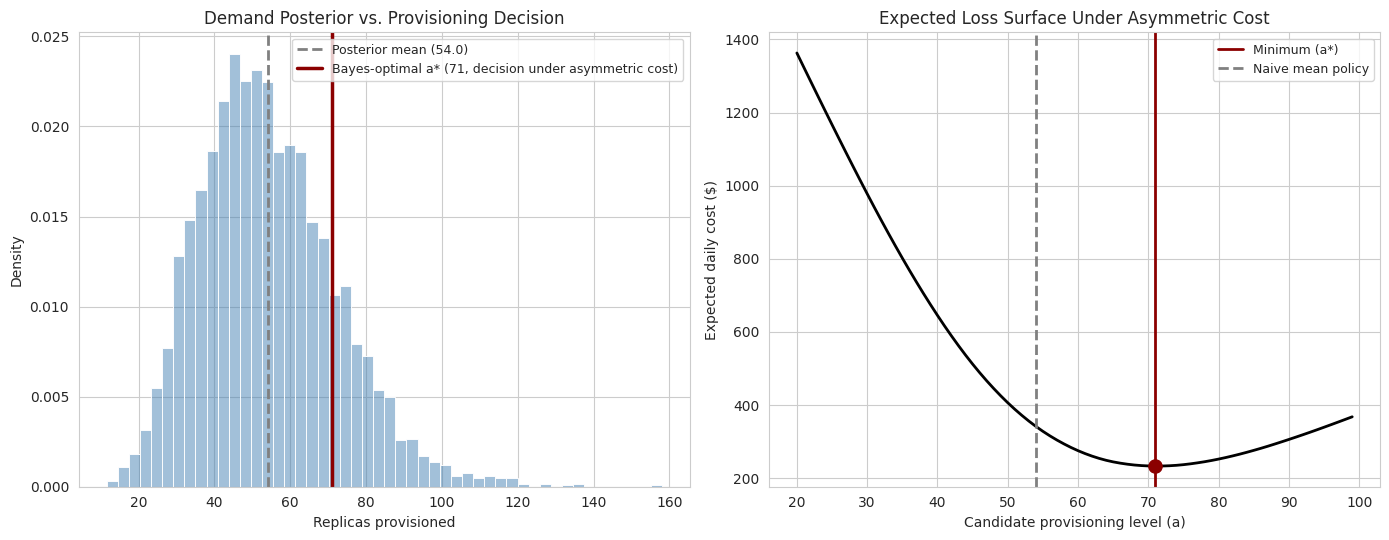

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(posterior_demand_samples, bins=50, stat="density", ax=axes[0], color="steelblue", alpha=0.5)
axes[0].axvline(posterior_demand_samples.mean(), color="gray", linestyle="--", linewidth=2,
                label=f"Posterior mean ({posterior_demand_samples.mean():.1f})")
axes[0].axvline(a_star, color="darkred", linestyle="-", linewidth=2.5,
                label=f"Bayes-optimal a* ({a_star}, decision under asymmetric cost)")
axes[0].set_xlabel("Replicas provisioned")
axes[0].set_title("Demand Posterior vs. Provisioning Decision")
axes[0].legend(fontsize=9)

axes[1].plot(candidate_a, losses, color="black", linewidth=2)
axes[1].axvline(a_star, color="darkred", linestyle="-", linewidth=2, label="Minimum (a*)")
axes[1].axvline(mean_action, color="gray", linestyle="--", linewidth=2, label="Naive mean policy")
axes[1].scatter([a_star], [loss_at_astar], color="darkred", s=90, zorder=5, clip_on=False)
axes[1].set_xlabel("Candidate provisioning level (a)")
axes[1].set_ylabel("Expected daily cost ($)")
axes[1].set_title("Expected Loss Surface Under Asymmetric Cost")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("decision_theory_provisioning.png", dpi=120)
plt.show()

*(Insight: the loss curve on the right is asymmetric — it rises steeply to the left of a* (under-provisioning is expensive) and gently to the right (over-provisioning is cheap) — that asymmetric shape, not the posterior alone, is what pulls the optimal decision above the mean. Communicating this shape, not just "a*=X", is what turns a statistics result into a decision stakeholders will trust.)*

## Real-World Use Case or Analogy

**The Emergency Room Staffing Director.** A hospital forecasting tomorrow's ER patient volume faces a textbook asymmetric-loss decision: understaffing risks patient harm and reputational/legal cost (very high $L$), while overstaffing just costs idle nurse wages (low $L$). No competent staffing director schedules to the *average* expected patient count — they schedule to a high percentile of the forecast distribution, precisely mirroring the newsvendor quantile rule. When a hospital board asks "why are we paying for capacity we don't usually need," the director doesn't show a posterior density plot — they show the **expected-cost-vs-staffing curve** (this lesson's right-hand chart) and say: "this is the point where the cost of being caught short outweighs the cost of the extra nurse." That is decision-theoretic risk communication: translating a distribution into one number, and one honest sentence about the asymmetry that produced it.